In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


Loading Spam Detection Dataset

In [2]:
data = pd.read_csv('/home/lucifer/Documents/Tech_Manthan/Logistic_Regression/data/spam_detection_dataset.csv')
data.head()


,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [3]:
## viewing the dataset size
data.shape

(20000, 6)

In [4]:
data.describe()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.694248,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.188312,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.567073,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.699740,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.834083,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [6]:
data.isnull().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

No null dataset

In [7]:
## checking duplicate data
data.duplicated().sum()

np.int64(402)

In [8]:
data = data.drop_duplicates()

In [9]:
data.shape

(19598, 6)

In [10]:
## viewing the count of spam and non-spam class mail
data['is_spam'].value_counts()

is_spam
0    17765
1     1833
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of spam and non-spam')

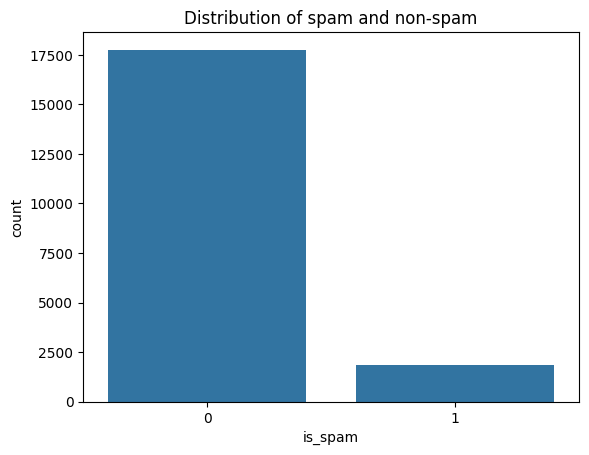

In [11]:
sns.countplot(data=data,x='is_spam')
plt.title('Distribution of spam and non-spam')

In [78]:
print("\nClass Distribution (Percentage):")
print(data['is_spam'].value_counts(normalize=True) * 100)


Class Distribution (Percentage):
is_spam
0    90.647005
1     9.352995
Name: proportion, dtype: float64


There seems to be class imbalance in the dataset

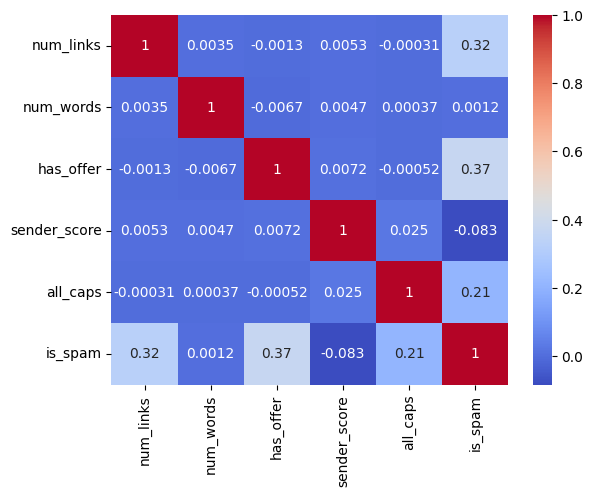

In [12]:
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop("is_spam",axis=1)
y = data['is_spam']

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [15]:
X_train_scaled.shape

(15678, 5)

In [14]:
X_val_scaled.shape

(3920, 5)

Implementing Logistic Regression From Scratch

In [16]:
## Defining LogisticRegression class

class LogisticRegression:
    def __init__(self,learning_rate=0.001,n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None 
        self.losses = []

    def _sigmoid(self,x):
        return 1 / (1+np.exp(-x))

    def compute_loss(self,y_true,y_pred):
        # Binary Cross Entropy loss
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred+epsilon)
        y2 = (1-y_true) * np.log(1-y_pred+epsilon)
        return -np.mean(y1+y2)
   

    def feed_forward(self,X):
        z = np.dot(X,self.weights) + self.bias
        A = self._sigmoid(z)
        return A

    def fit(self,X,y):
        n_samples,n_features = X.shape

        # initializing parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # gradient descent
        for _ in range(self.n_iters):
            A = self.feed_forward(X)
            loss = self.compute_loss(y,A)
            self.losses.append(loss)
            
            dz = A - y
            dw = (1/n_samples) * np.dot(X.T,dz)
            db = (1/n_samples) * np.sum(dz)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self,X):
        y_hat = np.dot(X,self.weights) + self.bias
        y_predicted = self._sigmoid(y_hat)
        y_predicted_cls = [1 if i> 0.5 else 0 for i in y_predicted]

        return np.array(y_predicted_cls)

    def accuracy(self,y,y_hat):
        accuracy = np.sum(y == y_hat) / len(y)
        return accuracy



In [17]:
regressor = LogisticRegression(learning_rate=0.001,n_iters=1000)
regressor.fit(X_train_scaled,y_train)

In [18]:
predictions = regressor.predict(X_val_scaled)

In [19]:
predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(3920,))

In [20]:
accuracy = regressor.accuracy(y_val,predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9104591836734693


Classification Report for Custom Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3540
           1       0.91      0.08      0.15       380

    accuracy                           0.91      3920
   macro avg       0.91      0.54      0.55      3920
weighted avg       0.91      0.91      0.88      3920



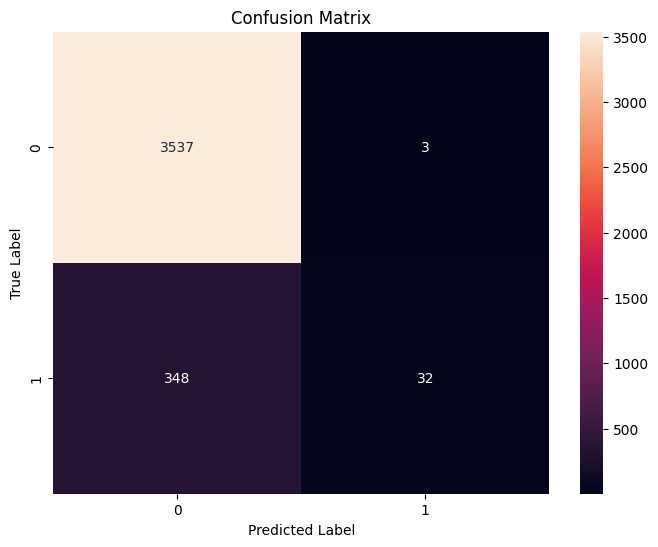

In [21]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

# Print the classification report
print("Classification Report for Custom Logistic Regression:")
print(classification_report(y_val, predictions))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, predictions), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Plotting the Training Loss

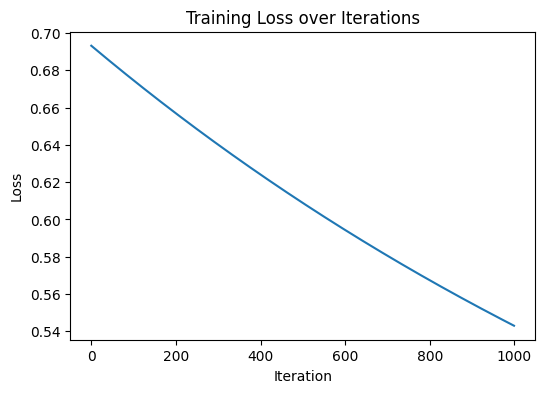

In [22]:
plt.figure(figsize=(6,4))
plt.plot(regressor.losses)
plt.title('Training Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

## With Regularization

In [50]:
class LogisticRegressionRegularization:
    def __init__(self, lr=0.01, n_iter=1000, lambda_=0.01):
        self.lr = lr
        self.n_iter = n_iter
        self.lambda_ = lambda_
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, y_true, y_pred):
        # binary cross entropy
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1 - y_true) * np.log(1 - y_pred + epsilon)
        n_samples = len(y_true)
        reg_term = (self.lambda_/(2*n_samples)) * np.sum(self.weights ** 2)
        return -np.mean(y1 + y2) + reg_term

    def feed_forward(self,X):
        z = np.dot(X,self.weights) + self.bias
        A = self.sigmoid(z)
        return A
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            # Forward pass
            predictions = self.feed_forward(X)
            
        
            loss = self.compute_loss(y,predictions)
            self.losses.append(loss)

            dw = (1 / n_samples) * (np.dot(X.T, (predictions - y)) + self.lambda_ * self.weights)
            db = (1 / n_samples) * np.sum(predictions - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_pred)
        return (y_pred >= 0.5).astype(int)
    
    def predict_proba(self,X):
        linear_pred = np.dot(X,self.weights) + self.bias
        return self.sigmoid(linear_pred)

In [51]:
custom_model = LogisticRegressionRegularization(lr=0.01, n_iter=1000)
custom_model.fit(X_train_scaled, y_train)

Classification Report for Custom Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3540
           1       0.81      0.12      0.21       380

    accuracy                           0.91      3920
   macro avg       0.86      0.56      0.58      3920
weighted avg       0.90      0.91      0.88      3920



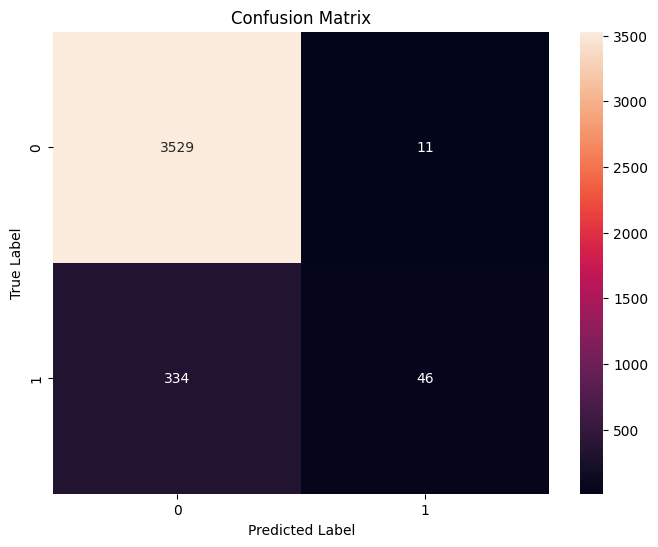

In [52]:
y_pred = custom_model.predict(X_val_scaled)
# Print the classification report
print("Classification Report for Custom Logistic Regression:")
print(classification_report(y_val, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

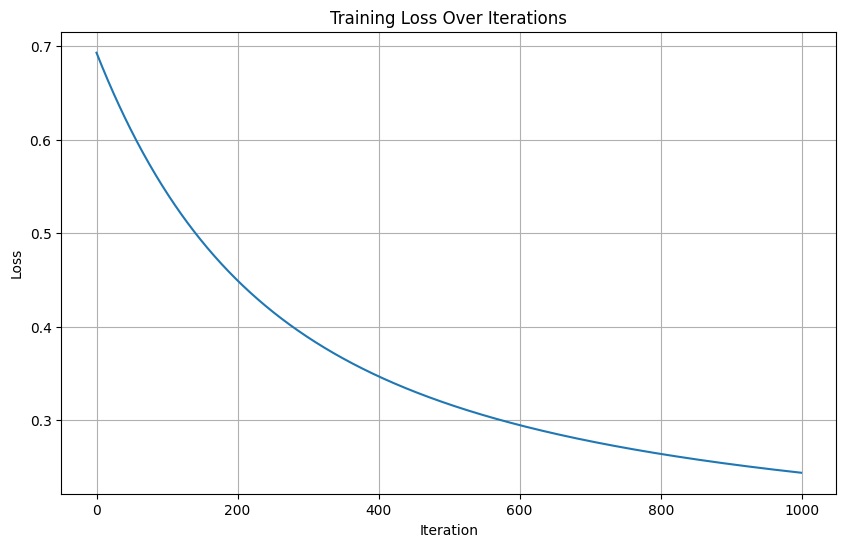

In [53]:
# Plot the training loss
plt.figure(figsize=(10,6))
plt.plot(custom_model.losses)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Training sklearn model for comparison

In [54]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(random_state=42,max_iter=1000)
sklearn_model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
sklearn_predictions = sklearn_model.predict(X_val_scaled)
sklearn_probs = sklearn_model.predict_proba(X_val)[:,1]

/home/lucifer/Documents/Tech_Manthan/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Classification Report for sklearn Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3540
           1       0.81      0.52      0.63       380

    accuracy                           0.94      3920
   macro avg       0.88      0.76      0.80      3920
weighted avg       0.94      0.94      0.94      3920



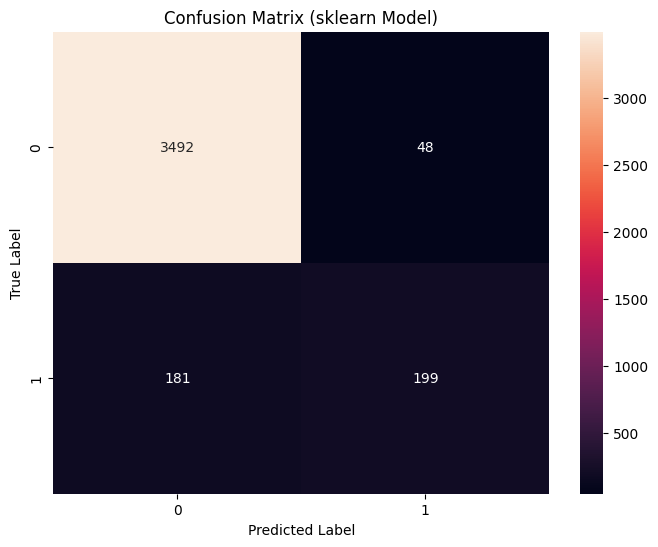

In [56]:
# Print sklearn model results
print("Classification Report for sklearn Logistic Regression:")
print(classification_report(y_val, sklearn_predictions))

# Plot confusion matrix for sklearn model
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, sklearn_predictions), annot=True, fmt='d')
plt.title('Confusion Matrix (sklearn Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

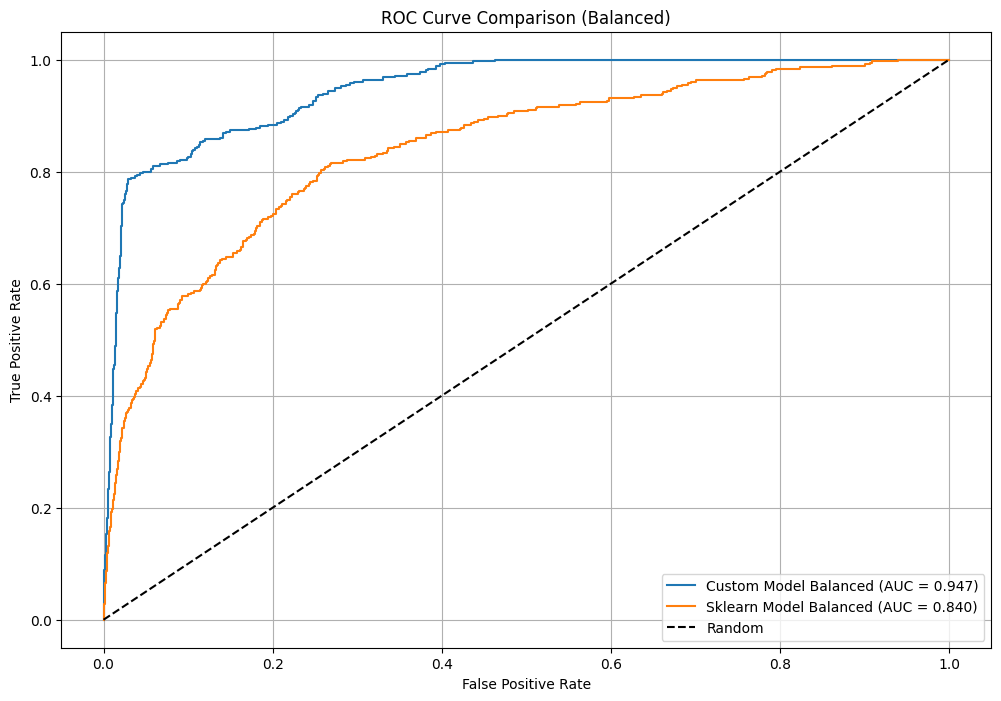

In [77]:
from sklearn.metrics import roc_curve,auc


# Calculate ROC curves for balanced models
custom_probs_balanced = custom_model.sigmoid(np.dot(X_val_scaled, custom_model.weights) + custom_model.bias)
fpr_custom_balanced, tpr_custom_balanced, _ = roc_curve(y_val, custom_probs_balanced)
fpr_sklearn_balanced, tpr_sklearn_balanced, _ = roc_curve(y_val, sklearn_probs)

# Calculate AUC
auc_custom_balanced = auc(fpr_custom_balanced, tpr_custom_balanced)
auc_sklearn_balanced = auc(fpr_sklearn_balanced, tpr_sklearn_balanced)

# Plot ROC curves
plt.figure(figsize=(12,8))
plt.plot(fpr_custom_balanced, tpr_custom_balanced, 
         label=f'Custom Model Balanced (AUC = {auc_custom_balanced:.3f})')
plt.plot(fpr_sklearn_balanced, tpr_sklearn_balanced, 
         label=f'Sklearn Model Balanced (AUC = {auc_sklearn_balanced:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Balanced)')
plt.legend()
plt.grid(True)
plt.show()


Handling class imbalance

In [65]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Use RandomUnderSampler to balance the dataset
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train_scaled, y_train)


In [66]:
# Check the original class distribution
print("Original class distribution:", Counter(y))
# Check the new class distribution after undersampling
print("New class distribution after undersampling:", Counter(y_train_resampled))


Original class distribution: Counter({0: 17765, 1: 1833})
New class distribution after undersampling: Counter({0: 1453, 1: 1453})


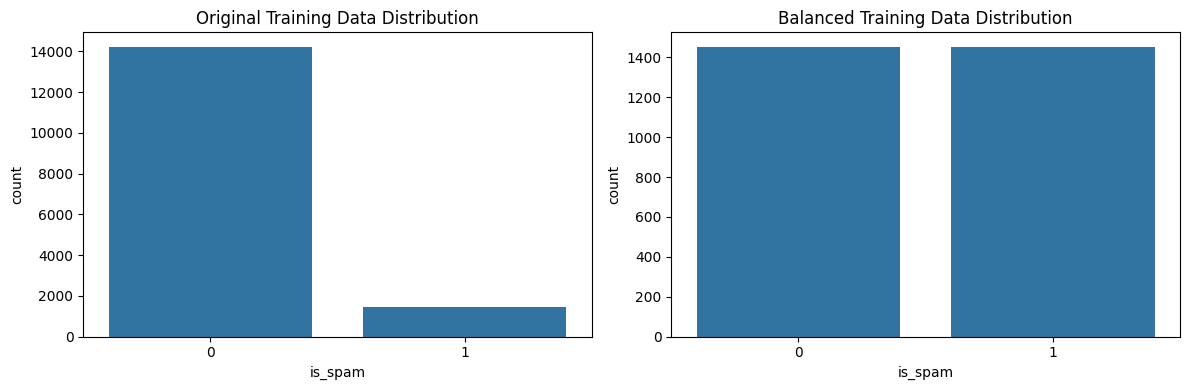

In [67]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Original Training Data Distribution")

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_resampled)
plt.title("Balanced Training Data Distribution")
plt.tight_layout()
plt.show()

Classification Report for Custom Logistic Regression (Balanced Data):
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      3540
           1       0.30      0.93      0.46       380

    accuracy                           0.79      3920
   macro avg       0.65      0.85      0.66      3920
weighted avg       0.92      0.79      0.83      3920



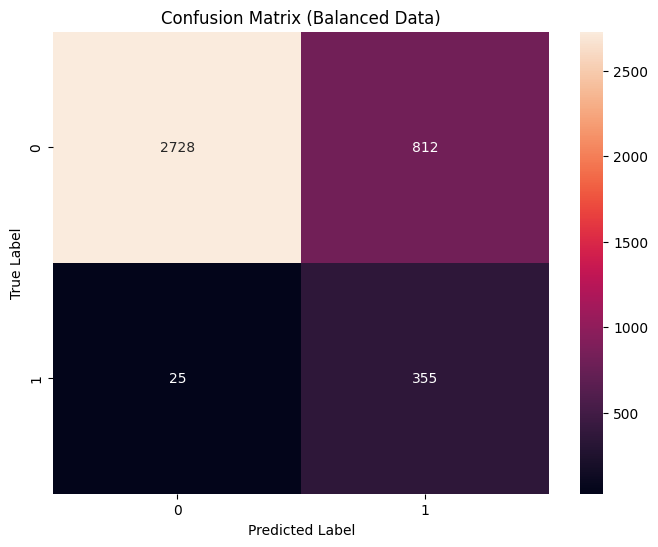

In [69]:
# Train custom model on balanced data
custom_model_balanced = LogisticRegressionRegularization(lr=0.01, n_iter=1000, lambda_=0.01)
custom_model_balanced.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_balanced = custom_model_balanced.predict(X_val_scaled)

# Print classification report
print("Classification Report for Custom Logistic Regression (Balanced Data):")
print(classification_report(y_val, y_pred_balanced))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred_balanced), annot=True, fmt='d')
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Sampling technique SMOTE (Synthetic Minority Over-sampling Technique) 
Generates new synthetic data points for the minority class by interpolating between existing samples and their nearest neighbours. This technique avoids simply duplicating data and helps improve learning by introducing more variation.

In [72]:
from imblearn.over_sampling import SMOTE

original_class_distribution = Counter(y)
print("Original Class Distribution:",original_class_distribution)

smote = SMOTE(sampling_strategy='auto',random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(X_train_scaled,y_train)

# checking new class distribution after smote
new_class_distribution = Counter(y_train_smote)

print("New class distribution after SMOTE:", new_class_distribution)

Original Class Distribution: Counter({0: 17765, 1: 1833})
New class distribution after SMOTE: Counter({0: 14225, 1: 14225})


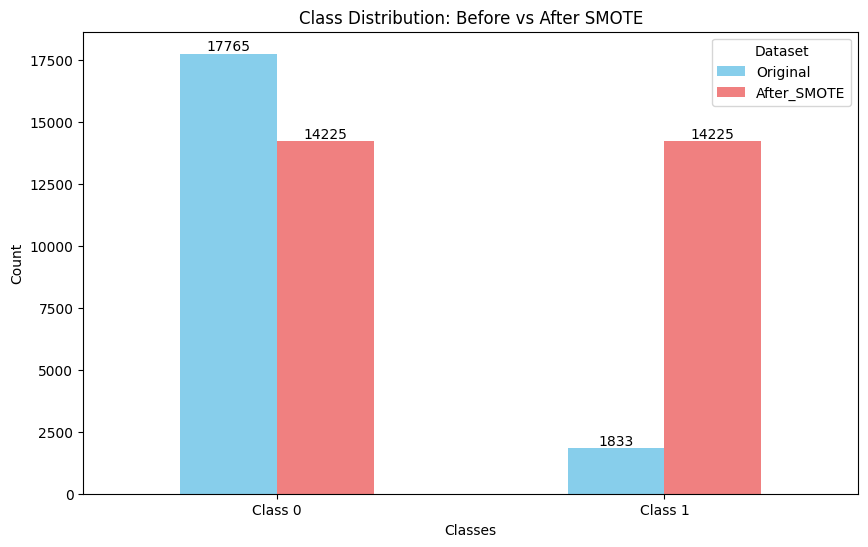

In [73]:
import pandas as pd

# Create DataFrame for easier plotting
df_comparison = pd.DataFrame({
    'Original': [original_class_distribution[0], original_class_distribution[1]], 
    'After_SMOTE': [new_class_distribution[0], new_class_distribution[1]]
}, index=['Class 0', 'Class 1'])

# Plot
ax = df_comparison.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Class Distribution: Before vs After SMOTE')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

Training the model on balanced data

Classification Report for Custom Logistic Regression (Balanced Data):
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      3540
           1       0.30      0.93      0.46       380

    accuracy                           0.78      3920
   macro avg       0.65      0.85      0.66      3920
weighted avg       0.92      0.78      0.83      3920



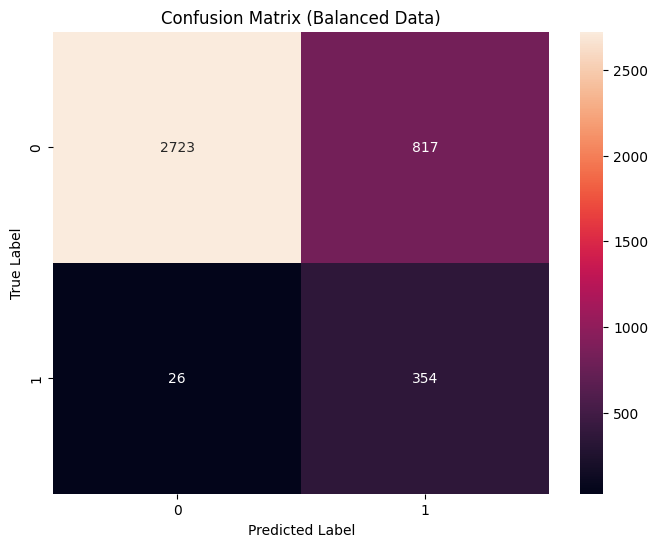

In [74]:
# Train custom model on balanced data
custom_model_balanced = LogisticRegressionRegularization(lr=0.01, n_iter=1000, lambda_=0.01)
custom_model_balanced.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_balanced = custom_model_balanced.predict(X_val_scaled)

# Print classification report
print("Classification Report for Custom Logistic Regression (Balanced Data):")
print(classification_report(y_val, y_pred_balanced))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred_balanced), annot=True, fmt='d')
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Classification Report for Sklearn Logistic Regression (Balanced Data):
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3540
           1       0.41      0.88      0.56       380

    accuracy                           0.86      3920
   macro avg       0.70      0.87      0.74      3920
weighted avg       0.93      0.86      0.88      3920



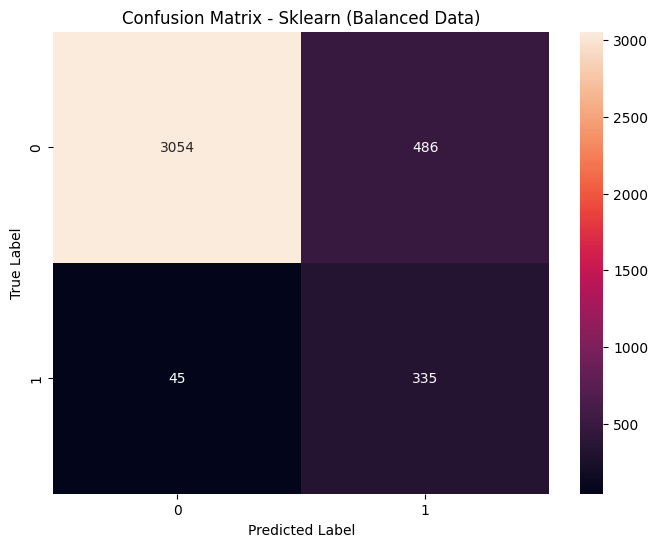

In [75]:
# Train sklearn model on balanced data
sklearn_model_balanced = LogisticRegression(random_state=42, max_iter=1000)
sklearn_model_balanced.fit(X_train_smote, y_train_smote)

# Get predictions
sklearn_preds_balanced = sklearn_model_balanced.predict(X_val_scaled)
sklearn_probs_balanced = sklearn_model_balanced.predict_proba(X_val_scaled)[:, 1]

# Print classification report
print("Classification Report for Sklearn Logistic Regression (Balanced Data):")
print(classification_report(y_val, sklearn_preds_balanced))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, sklearn_preds_balanced), annot=True, fmt='d')
plt.title('Confusion Matrix - Sklearn (Balanced Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

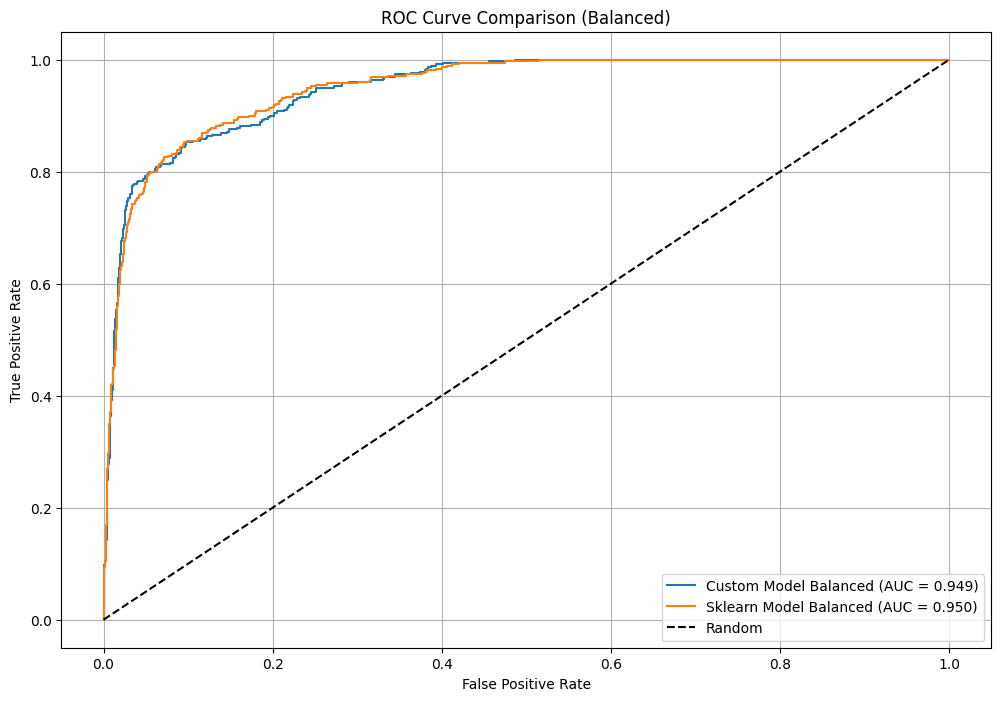

In [76]:
# Calculate ROC curves for balanced models
custom_probs_balanced = custom_model_balanced.sigmoid(np.dot(X_val_scaled, custom_model_balanced.weights) + custom_model_balanced.bias)
fpr_custom_balanced, tpr_custom_balanced, _ = roc_curve(y_val, custom_probs_balanced)
fpr_sklearn_balanced, tpr_sklearn_balanced, _ = roc_curve(y_val, sklearn_probs_balanced)

# Calculate AUC
auc_custom_balanced = auc(fpr_custom_balanced, tpr_custom_balanced)
auc_sklearn_balanced = auc(fpr_sklearn_balanced, tpr_sklearn_balanced)

# Plot ROC curves
plt.figure(figsize=(12,8))
plt.plot(fpr_custom_balanced, tpr_custom_balanced, 
         label=f'Custom Model Balanced (AUC = {auc_custom_balanced:.3f})')
plt.plot(fpr_sklearn_balanced, tpr_sklearn_balanced, 
         label=f'Sklearn Model Balanced (AUC = {auc_sklearn_balanced:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Balanced)')
plt.legend()
plt.grid(True)
plt.show()

### Why is accuracy not a suitable evaluation metric for all cases?

Accuracy can be misleading in imbalanced datasets, in our email spam classification problem:

Class Distribution:

Non-spam: 90.65%

Spam: 9.35%

A naive model that predicts every email as non-spam would still achieve 90.65% accuracy,
even though it completely fails to detect spam.

 This results in a false sense of high performance, especially when the minority class is more important.

 Instead, consider metrics like:

- Precision (how many predicted spams are actually spam),

- Recall (how many actual spams are detected), or

- AUC-ROC (model's ability to distinguish between classes).



### When to choose precision over recall and vice-versa?

Choose Precision when false positives are costly:
- e.g., marking important non-spam emails as spam (false alarms).
Use precision when you want to avoid mistakenly flagging good emails.

 Choose Recall when false negatives are risky:
- e.g., letting actual spam enter the inbox undetected.
Use recall when you want to catch as much spam as possible, even if a few good emails are misclassified.